# Modelos de clasificación: parrilla completa, selección y diagnóstico

**CC3084 · Ciencia de Datos · Universidad del Valle de Guatemala · Semestre II, 2026**

Este cuaderno cubre el **ejercicio 6** de la entrega final. El cuaderno 04 dejó un modelo
preliminar elegido entre cinco combinaciones; aquí se amplía a la parrilla completa que pide
el enunciado (*"Elabore varios modelos... Puede utilizar varios algoritmos"*), se responde la
pregunta sobre cómo se aborda el contexto, y se selecciona el mejor modelo con un criterio
escrito **antes** de mirar los resultados.

El plan de trabajo:

1. Cargar la partición congelada y **reproducir el resultado del avance** como prueba de control.
2. Parrilla de **3 algoritmos × 2 representaciones × 2 reducciones = 12 combinaciones**.
3. Random Forest como cuarto algoritmo, para poner a prueba la advertencia del material de
   clase sobre los bosques y las matrices dispersas.
4. **Variantes de contexto**: unigramas contra bigramas contra trigramas, n-gramas de
   caracteres y `keyword` como característica.
5. **Validación cruzada** de las mejores combinaciones sobre el conjunto de entrenamiento.
6. Selección del ganador con el criterio pre-declarado.
7. Diagnóstico: matriz de confusión, coeficientes y **análisis de errores tipificado**.
8. Guardar el modelo en `results/modelos/mejor_modelo.joblib`.

In [1]:
import sys
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             classification_report)

RAIZ = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(RAIZ / 'src'))

import config
import modelos as M

config.asegurar_directorios()
warnings.filterwarnings('ignore', category=FutureWarning)

plt.rcParams['figure.dpi'] = 110
plt.rcParams['savefig.dpi'] = config.FIG_DPI
plt.rcParams['savefig.bbox'] = 'tight'
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

pd.set_option('display.width', 180)
pd.set_option('display.max_colwidth', 95)


def guardar(fig, nombre):
    fig.savefig(config.FIGURES / nombre)
    print(f'figura guardada: results/figures/{nombre}')


def guardar_tabla(df, nombre):
    df.to_csv(config.TABLES / nombre, index=False)
    print(f'tabla guardada: results/tables/{nombre}  ({len(df)} filas)')


print('Entorno listo.')

Entorno listo.


## La partición congelada y la prueba de control

Todo el laboratorio comparte una única partición, guardada en
`data/processed/particion.parquet` como una lista de `id` con el lado que le tocó a cada
tweet. No se vuelve a partir aquí: se **lee**.

El motivo es que `train_test_split` con la misma semilla devuelve la misma partición solo si
recibe las filas en el mismo orden. Basta con que alguien filtre el DataFrame o cambie la
regla de deduplicación para que la partición se mueva sin que nadie lo note, y entonces el
modelo del ejercicio 10 estaría midiéndose contra un conjunto de prueba distinto al del
ejercicio 6. La comparación quedaría inservible **y parecería válida**.

La primera celda hace además una prueba de control: reentrena la combinación ganadora del
avance y verifica que da exactamente el mismo número. Si no coincidiera, algo cambió en la
cadena de datos y habría que resolverlo antes de seguir.

In [2]:
entrenamiento, prueba = M.cargar_particion()

X_tr_clean, X_te_clean = entrenamiento['text_clean'], prueba['text_clean']
X_tr_stem, X_te_stem = entrenamiento['text_stem'], prueba['text_stem']
y_tr, y_te = entrenamiento['target'], prueba['target']

resumen = pd.DataFrame({
    'entrenamiento': y_tr.value_counts().sort_index(),
    'prueba': y_te.value_counts().sort_index(),
    '% entrenamiento': (y_tr.value_counts(normalize=True).sort_index() * 100).round(2),
    '% prueba': (y_te.value_counts(normalize=True).sort_index() * 100).round(2),
})
resumen.index = resumen.index.map(config.ETIQUETAS)
resumen

Corpus procesado leído de corpus_procesado.parquet: 7,485 tweets
Partición congelada leída de particion.parquet
Entrenamiento: 5,988 tweets   Prueba: 1,497 tweets


,entrenamiento,prueba,% entrenamiento,% prueba
target,,,,
no desastre,3438,859,57.41,57.38
desastre,2550,638,42.59,42.62


In [3]:
# Prueba de control: la combinación ganadora del avance debe reproducirse al cuarto decimal.
control = M.evaluar(M.construir_pipeline('logreg', 'tfidf'),
                    X_tr_clean, y_tr, X_te_clean, y_te, 'control del avance')

ESPERADO = 0.7857
print(f"macro-F1 reproducido: {control['macro_f1']:.4f}   esperado del avance: {ESPERADO:.4f}")
assert abs(control['macro_f1'] - ESPERADO) < 5e-5, 'La cadena de datos cambió respecto al avance.'
print('Prueba de control superada: la partición y el preprocesamiento son los mismos del avance.')

macro-F1 reproducido: 0.7857   esperado del avance: 0.7857
Prueba de control superada: la partición y el preprocesamiento son los mismos del avance.


**Interpretación.** La partición mantiene la estratificación (57.41% / 42.59% en
entrenamiento contra 57.38% / 42.62% en prueba) y la prueba de control se supera: el modelo
del avance devuelve exactamente 0.7857 de macro-F1. Los resultados de este cuaderno son
comparables con los del avance y con los del ejercicio 10 sin ningún ajuste.

## La parrilla: 3 algoritmos × 2 representaciones × 2 reducciones

Las tres dimensiones que se cruzan:

| Dimensión | Opciones | Qué se está probando |
|---|---|---|
| Algoritmo | Regresión logística, SVM lineal, ComplementNB | La forma de la frontera de decisión |
| Representación | Bolsa de palabras, TF-IDF | Si conviene ponderar los términos por su rareza |
| Reducción | Lematización (`text_clean`), *stemming* (`text_stem`) | Cuál de las dos normalizaciones de B conserva más señal |

Los tres algoritmos no son intercambiables, cada uno aporta un argumento distinto:

- **Regresión logística** es lineal y sus coeficientes son legibles, lo que permite explicar
  *qué* aprendió el modelo. Con `class_weight='balanced'` compensa el desbalance 57/43
  penalizando más los errores sobre la clase de interés.
- **SVM lineal** optimiza el margen en lugar de la verosimilitud. Suele rendir bien en texto
  disperso y de dimensión alta.
- **ComplementNB** es la variante de Naive Bayes diseñada explícitamente para clases
  desbalanceadas: estima los parámetros de cada clase a partir del complemento de las demás.

Una nota sobre la bolsa de palabras: se usa `CountVectorizer`, es decir la cuenta cruda de
cada término, que es la definición de bolsa de palabras del material de clase y la entrada
que Naive Bayes espera. Todas las combinaciones usan `ngram_range=(1,2)` y `min_df=2` para
que la única diferencia entre ellas sea la que se está midiendo; el rango de n-gramas se
explora aparte, en la sección de contexto.

Cada combinación se evalúa por separado y se imprime su resultado, para que cada número sea
rastreable a la línea que lo produjo.

### Regresión logística

In [4]:
resultados = []


# Evalúa una combinación de la parrilla, la registra e imprime su resultado.
def combinar(algoritmo, representacion, reduccion, **opciones):
    columna = 'text_clean' if reduccion == 'lema' else 'text_stem'
    etiqueta = f'{representacion.upper()} + {M.NOMBRES_ALGORITMO[algoritmo]} ({reduccion})'
    fila = M.evaluar(
        M.construir_pipeline(algoritmo, representacion, **opciones),
        entrenamiento[columna], y_tr, prueba[columna], y_te, etiqueta)
    fila['reduccion'] = reduccion
    resultados.append(fila)
    print(f"{etiqueta:52s} macro-F1 = {fila['macro_f1']:.4f}   "
          f"recall desastre = {fila['recall_desastre']:.4f}")
    return fila


combinar('logreg', 'bow', 'lema')
combinar('logreg', 'bow', 'stem')
combinar('logreg', 'tfidf', 'lema')
combinar('logreg', 'tfidf', 'stem')

BOW + Regresión logística (lema)                     macro-F1 = 0.7766   recall desastre = 0.6865


BOW + Regresión logística (stem)                     macro-F1 = 0.7687   recall desastre = 0.6755


TFIDF + Regresión logística (lema)                   macro-F1 = 0.7857   recall desastre = 0.7241


TFIDF + Regresión logística (stem)                   macro-F1 = 0.7826   recall desastre = 0.7163


{'modelo': 'TFIDF + Regresión logística (stem)',
 'representacion': 'TfidfVectorizer',
 'detalle': 'word (1, 2)',
 'algoritmo': 'LogisticRegression',
 'accuracy': 0.7895791583166333,
 'precision_no_desastre': np.float64(0.8002207505518764),
 'recall_no_desastre': np.float64(0.8440046565774156),
 'f1_no_desastre': np.float64(0.8215297450424929),
 'precision_desastre': np.float64(0.7732656514382402),
 'recall_desastre': np.float64(0.7163009404388715),
 'f1_desastre': np.float64(0.7436940602115542),
 'macro_f1': 0.7826119026270235,
 'prediccion': array([1, 1, 0, ..., 0, 1, 1], shape=(1497,)),
 'pipeline': Pipeline(steps=[('vec', TfidfVectorizer(min_df=2, ngram_range=(1, 2))),
                 ('clf',
                  LogisticRegression(class_weight='balanced', max_iter=1000,
                                     random_state=42))]),
 'reduccion': 'stem'}

### SVM lineal

In [5]:
combinar('svc', 'bow', 'lema')
combinar('svc', 'bow', 'stem')
combinar('svc', 'tfidf', 'lema')
combinar('svc', 'tfidf', 'stem')

BOW + SVM lineal (lema)                              macro-F1 = 0.7511   recall desastre = 0.6677


BOW + SVM lineal (stem)                              macro-F1 = 0.7530   recall desastre = 0.6834
TFIDF + SVM lineal (lema)                            macro-F1 = 0.7697   recall desastre = 0.7038


TFIDF + SVM lineal (stem)                            macro-F1 = 0.7580   recall desastre = 0.6912


{'modelo': 'TFIDF + SVM lineal (stem)',
 'representacion': 'TfidfVectorizer',
 'detalle': 'word (1, 2)',
 'algoritmo': 'LinearSVC',
 'accuracy': 0.7655310621242485,
 'precision_no_desastre': np.float64(0.7815964523281597),
 'recall_no_desastre': np.float64(0.8207217694994179),
 'f1_no_desastre': np.float64(0.8006814310051107),
 'precision_desastre': np.float64(0.7411764705882353),
 'recall_desastre': np.float64(0.6912225705329154),
 'f1_desastre': np.float64(0.7153284671532847),
 'macro_f1': 0.7580049490791977,
 'prediccion': array([1, 1, 0, ..., 0, 1, 1], shape=(1497,)),
 'pipeline': Pipeline(steps=[('vec', TfidfVectorizer(min_df=2, ngram_range=(1, 2))),
                 ('clf', LinearSVC(class_weight='balanced', random_state=42))]),
 'reduccion': 'stem'}

### ComplementNB

In [6]:
combinar('cnb', 'bow', 'lema')
combinar('cnb', 'bow', 'stem')
combinar('cnb', 'tfidf', 'lema')
combinar('cnb', 'tfidf', 'stem')

BOW + ComplementNB (lema)                            macro-F1 = 0.7789   recall desastre = 0.6755


BOW + ComplementNB (stem)                            macro-F1 = 0.7861   recall desastre = 0.6787
TFIDF + ComplementNB (lema)                          macro-F1 = 0.7839   recall desastre = 0.6755


TFIDF + ComplementNB (stem)                          macro-F1 = 0.7791   recall desastre = 0.6708


{'modelo': 'TFIDF + ComplementNB (stem)',
 'representacion': 'TfidfVectorizer',
 'detalle': 'word (1, 2)',
 'algoritmo': 'ComplementNB',
 'accuracy': 0.7895791583166333,
 'precision_no_desastre': np.float64(0.7821576763485477),
 'recall_no_desastre': np.float64(0.8777648428405123),
 'f1_no_desastre': np.float64(0.8272078990674712),
 'precision_desastre': np.float64(0.8030018761726079),
 'recall_desastre': np.float64(0.670846394984326),
 'f1_desastre': np.float64(0.730999146029035),
 'macro_f1': 0.7791035225482531,
 'prediccion': array([1, 1, 0, ..., 0, 1, 0], shape=(1497,)),
 'pipeline': Pipeline(steps=[('vec', TfidfVectorizer(min_df=2, ngram_range=(1, 2))),
                 ('clf', ComplementNB())]),
 'reduccion': 'stem'}

### El cuarto algoritmo: Random Forest

El material de clase advierte que los modelos de árboles sufren con matrices muy dispersas:
cada división mira una sola característica, y con un vocabulario de decenas de miles de
términos donde cada tweet activa una fracción mínima, la mayoría de divisiones aporta poco.
Vale la pena incluirlo y comprobar si la advertencia se sostiene con estos datos.

In [7]:
for representacion in ['bow', 'tfidf']:
    combinar('rf', representacion, 'lema')

BOW + Random Forest (lema)                           macro-F1 = 0.7677   recall desastre = 0.6708


TFIDF + Random Forest (lema)                         macro-F1 = 0.7600   recall desastre = 0.6552


In [8]:
tabla_parrilla = M.tabla_metricas(resultados)
guardar_tabla(tabla_parrilla, 'modelos_parrilla_completa.csv')

vista = ['modelo', 'accuracy', 'precision_desastre', 'recall_desastre',
         'f1_desastre', 'macro_f1']
tabla_parrilla[vista].round(4)

tabla guardada: results/tables/modelos_parrilla_completa.csv  (14 filas)


,modelo,accuracy,precision_desastre,recall_desastre,f1_desastre,macro_f1
0,BOW + ComplementNB (stem),0.7963,0.8124,0.6787,0.7395,0.7861
1,TFIDF + Regresión logística (lema),0.7923,0.7739,0.7241,0.7482,0.7857
2,TFIDF + ComplementNB (lema),0.7943,0.8102,0.6755,0.7368,0.7839
3,TFIDF + Regresión logística (stem),0.7896,0.7733,0.7163,0.7437,0.7826
4,TFIDF + ComplementNB (stem),0.7896,0.8030,0.6708,0.7310,0.7791
5,BOW + ComplementNB (lema),0.7889,0.7981,0.6755,0.7317,0.7789
6,BOW + Regresión logística (lema),0.7856,0.7835,0.6865,0.7318,0.7766
7,TFIDF + SVM lineal (lema),0.7769,0.7559,0.7038,0.7289,0.7697
8,BOW + Regresión logística (stem),0.7782,0.7752,0.6755,0.7219,0.7687
9,BOW + Random Forest (lema),0.7776,0.7768,0.6708,0.7199,0.7677


figura guardada: results/figures/modelos_comparacion_parrilla.png


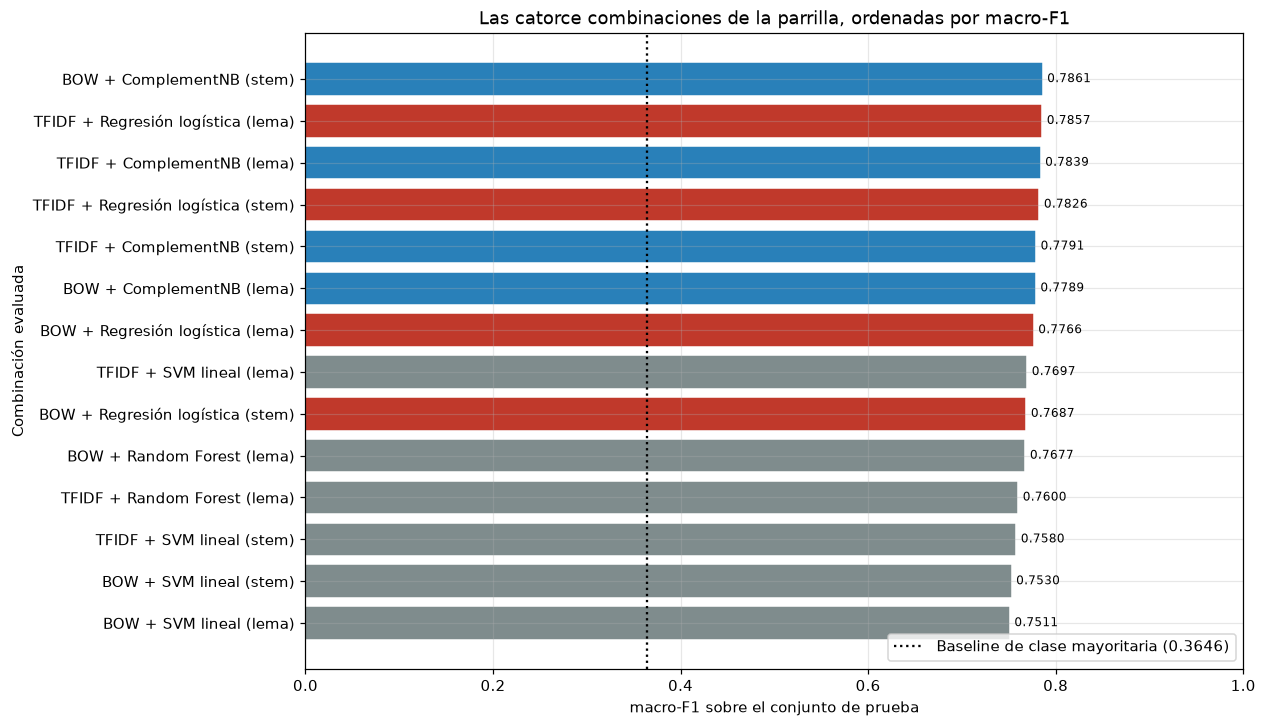

Rango de macro-F1 entre las 14 combinaciones: 0.7511 a 0.7861 (amplitud de 0.0350)

Promedio de macro-F1 por dimensión:

  por algoritmo:
                          mean     max
algoritmo                             
ComplementNB            0.7820  0.7861
LinearSVC               0.7579  0.7697
LogisticRegression      0.7784  0.7857
RandomForestClassifier  0.7639  0.7677

  por reducción:
             mean     max
reduccion                
lema       0.7717  0.7857
stem       0.7713  0.7861

  por representación:


                     mean     max
rep                              
Bolsa de palabras  0.7689  0.7861
TF-IDF             0.7742  0.7857


In [9]:
fig, ax = plt.subplots(figsize=(config.FIG_ANCHO + 1, config.FIG_ALTO + 2.5))
orden = tabla_parrilla.sort_values('macro_f1')
colores = [config.COLOR_DESASTRE if 'Regresión' in m
           else config.COLOR_NO_DESASTRE if 'ComplementNB' in m
           else config.COLOR_NEUTRO for m in orden.modelo]

barras = ax.barh(orden.modelo, orden.macro_f1, color=colores, edgecolor='white')
ax.bar_label(barras, fmt='%.4f', padding=3, fontsize=8)
ax.axvline(0.3646, color='black', linestyle=':', linewidth=1.5,
           label='Baseline de clase mayoritaria (0.3646)')
ax.set_xlim(0, 1.0)
ax.set_xlabel('macro-F1 sobre el conjunto de prueba')
ax.set_ylabel('Combinación evaluada')
ax.set_title('Las catorce combinaciones de la parrilla, ordenadas por macro-F1')
ax.legend(loc='lower right')
guardar(fig, 'modelos_comparacion_parrilla.png')
plt.show()

print(f'Rango de macro-F1 entre las 14 combinaciones: '
      f'{tabla_parrilla.macro_f1.min():.4f} a {tabla_parrilla.macro_f1.max():.4f} '
      f'(amplitud de {tabla_parrilla.macro_f1.max() - tabla_parrilla.macro_f1.min():.4f})')
print()
print('Promedio de macro-F1 por dimensión:')
for dimension, columna in [('algoritmo', 'algoritmo'), ('reducción', 'reduccion')]:
    print(f'\n  por {dimension}:')
    print(tabla_parrilla.groupby(columna).macro_f1.agg(['mean', 'max']).round(4).to_string())
print('\n  por representación:')
print(tabla_parrilla.assign(
    rep=np.where(tabla_parrilla.modelo.str.startswith('TFIDF'), 'TF-IDF', 'Bolsa de palabras')
).groupby('rep').macro_f1.agg(['mean', 'max']).round(4).to_string())

**Interpretación.** La amplitud entre la mejor y la peor de las catorce combinaciones es de
**0.0350 de macro-F1**, y todas superan al baseline de clase mayoritaria por más de 0.38. La
lectura es que el texto contiene señal abundante y que **la elección de algoritmo y
representación no es donde se gana**: el problema no está en el modelo sino en el lenguaje.

Tres resultados concretos por dimensión:

- **Algoritmo.** ComplementNB obtiene el mejor promedio (0.7820) y la mejor combinación
  individual (0.7861), con la regresión logística pisándole los talones (0.7784 de promedio,
  0.7857 la mejor). SVM lineal queda claramente por detrás (0.7579 de promedio): optimizar el
  margen sin calibrar el umbral penaliza a la clase minoritaria.
- **Reducción.** Lematización 0.7717 contra *stemming* 0.7713 de promedio. **Cuatro
  diezmilésimas**, es decir nada. Las dos normalizaciones que produjo el preprocesamiento son
  intercambiables para esta tarea, así que la decisión puede tomarse por otro motivo: la
  lematización devuelve palabras reales y los coeficientes del modelo se pueden leer, mientras
  que los del *stemming* quedan en fragmentos como `earthquak`.
- **Representación.** TF-IDF gana en promedio (0.7742 contra 0.7689), pero la mejor
  combinación individual usa bolsa de palabras. Ponderar por rareza ayuda, poco.

El detalle que obliga a no cerrar aquí: entre el primero (0.7861) y el segundo (0.7857) hay
**cuatro diezmilésimas de macro-F1**, que sobre 1,497 tweets de prueba equivale a menos de un
tweet de diferencia. Declarar un ganador con ese margen sería declarar un ganador al azar. Por
eso la selección no se hace con esta tabla sino con validación cruzada.

## Contexto: ¿cómo se aborda?

El enunciado pregunta de forma explícita cómo se planea abordar el contexto. Un modelo de
bolsa de palabras no tiene ninguno: para él *"no reported flooding"* y *"reported flooding"*
son casi el mismo documento. Hay tres formas de darle algo de contexto sin abandonar el
enfoque, y aquí se miden las tres en lugar de argumentarlas:

1. **Ampliar el rango de n-gramas.** Un bigrama une dos palabras contiguas en una sola
   característica, así que `oil spill` deja de ser `oil` + `spill`. El costo es la explosión
   del vocabulario.
2. **N-gramas de caracteres** (`char_wb`, 3 a 5). No conocen el concepto de palabra, así que
   absorben erratas, plurales y truncamientos —abundantes en Twitter— a cambio de perder
   toda interpretabilidad: sus características son fragmentos como `fir`, `ire`.
3. **Agregar `keyword`** como variable categórica junto al texto. El avance ya midió que
   empeora el modelo; se repite aquí sobre la parrilla completa para dejarlo cerrado.

In [10]:
contexto = []


def variante(etiqueta, algoritmo='logreg', representacion='tfidf',
             columna='text_clean', columnas_categoricas=None, **opciones):
    pipe = M.construir_pipeline(algoritmo, representacion, columna_texto=columna,
                                columnas_categoricas=columnas_categoricas, **opciones)
    if columnas_categoricas:
        cols = [columna] + columnas_categoricas
        fila = M.evaluar(pipe, entrenamiento[cols], y_tr, prueba[cols], y_te, etiqueta)
    else:
        fila = M.evaluar(pipe, entrenamiento[columna], y_tr, prueba[columna], y_te, etiqueta)

    # Tamaño del vocabulario: es el costo que se paga por el contexto.
    vec = (pipe.named_steps['vec'] if 'vec' in pipe.named_steps
           else pipe.named_steps['features'].named_transformers_['texto'])
    fila['vocabulario'] = len(vec.vocabulary_)

    contexto.append(fila)
    print(f"{etiqueta:46s} macro-F1 = {fila['macro_f1']:.4f}   "
          f"vocabulario = {fila['vocabulario']:>9,}")
    return fila


f11 = variante('Solo unigramas (1,1)', ngram_range=(1, 1))
f12 = variante('Unigramas + bigramas (1,2)', ngram_range=(1, 2))
f13 = variante('Uni + bi + trigramas (1,3)', ngram_range=(1, 3))
fch = variante('N-gramas de caracteres (3,5)', representacion='char',
               ngram_range=(3, 5), min_df=3)
fkw = variante('TF-IDF (1,2) + keyword one-hot',
               columnas_categoricas=['keyword_norm'])

tabla_contexto = M.tabla_metricas(contexto, ordenar=False)
guardar_tabla(tabla_contexto, 'modelos_variantes_contexto.csv')
tabla_contexto[['modelo', 'vocabulario', 'accuracy', 'recall_desastre', 'macro_f1']].round(4)

Solo unigramas (1,1)                           macro-F1 = 0.7856   vocabulario =     4,966


Unigramas + bigramas (1,2)                     macro-F1 = 0.7857   vocabulario =     9,308


Uni + bi + trigramas (1,3)                     macro-F1 = 0.7893   vocabulario =    12,142

N-gramas de caracteres (3,5)                   macro-F1 = 0.7743   vocabulario =    25,514
TF-IDF (1,2) + keyword one-hot                 macro-F1 = 0.7669   vocabulario =     9,308
tabla guardada: results/tables/modelos_variantes_contexto.csv  (5 filas)


,modelo,vocabulario,accuracy,recall_desastre,macro_f1
0,"Solo unigramas (1,1)",4966,0.7923,0.7226,0.7856
1,"Unigramas + bigramas (1,2)",9308,0.7923,0.7241,0.7857
2,"Uni + bi + trigramas (1,3)",12142,0.7956,0.7304,0.7893
3,"N-gramas de caracteres (3,5)",25514,0.7822,0.6975,0.7743
4,"TF-IDF (1,2) + keyword one-hot",9308,0.7729,0.7194,0.7669


figura guardada: results/figures/modelos_contexto.png


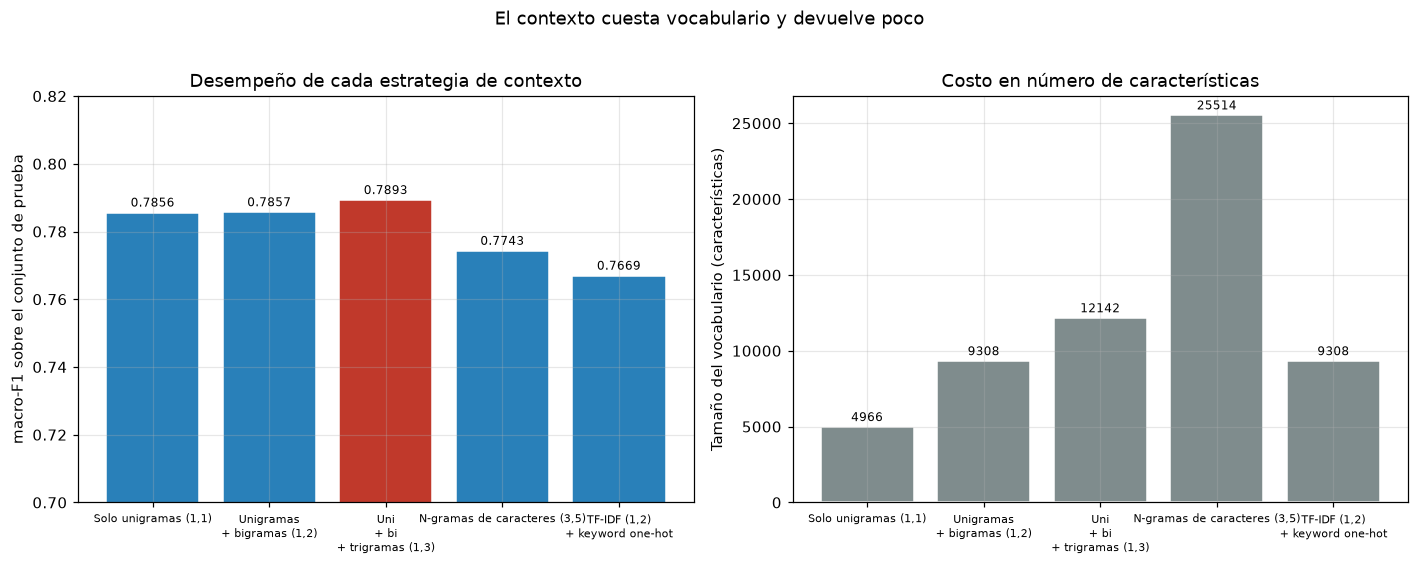

Unigramas -> bigramas: +0.0001 de macro-F1, a cambio de 4,342 características más (1.9 veces el vocabulario).
Bigramas -> trigramas: +0.0036 de macro-F1, a cambio de 2,834 características más.
Agregar keyword:       -0.0187 de macro-F1.


In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(config.FIG_ANCHO + 3, config.FIG_ALTO))

etiquetas = [f['modelo'].replace(' + ', '\n+ ') for f in contexto]
valores = [f['macro_f1'] for f in contexto]
colores = [config.COLOR_DESASTRE if v == max(valores) else config.COLOR_NO_DESASTRE
           for v in valores]
barras = ax1.bar(range(len(valores)), valores, color=colores, edgecolor='white')
ax1.bar_label(barras, fmt='%.4f', padding=2, fontsize=8)
ax1.set_xticks(range(len(valores)))
ax1.set_xticklabels(etiquetas, fontsize=7.5)
ax1.set_ylim(0.70, 0.82)
ax1.set_ylabel('macro-F1 sobre el conjunto de prueba')
ax1.set_title('Desempeño de cada estrategia de contexto')

vocab = [f['vocabulario'] for f in contexto]
barras2 = ax2.bar(range(len(vocab)), vocab, color=config.COLOR_NEUTRO, edgecolor='white')
ax2.bar_label(barras2, fmt='%d', padding=2, fontsize=8)
ax2.set_xticks(range(len(vocab)))
ax2.set_xticklabels(etiquetas, fontsize=7.5)
ax2.set_ylabel('Tamaño del vocabulario (características)')
ax2.set_title('Costo en número de características')

fig.suptitle('El contexto cuesta vocabulario y devuelve poco', y=1.02)
fig.tight_layout()
guardar(fig, 'modelos_contexto.png')
plt.show()

print(f'Unigramas -> bigramas: {f12["macro_f1"] - f11["macro_f1"]:+.4f} de macro-F1, '
      f'a cambio de {f12["vocabulario"] - f11["vocabulario"]:,} características más '
      f'({f12["vocabulario"] / f11["vocabulario"]:.1f} veces el vocabulario).')
print(f'Bigramas -> trigramas: {f13["macro_f1"] - f12["macro_f1"]:+.4f} de macro-F1, '
      f'a cambio de {f13["vocabulario"] - f12["vocabulario"]:,} características más.')
print(f'Agregar keyword:       {fkw["macro_f1"] - f12["macro_f1"]:+.4f} de macro-F1.')

**Interpretación: el contexto se aborda con n-gramas, y rinde poco.** Los tres experimentos
responden la pregunta del enunciado con números en lugar de argumentos.

Añadir bigramas a los unigramas mejora la macro-F1 en **+0.0001** —una diezmilésima— y a
cambio casi duplica el vocabulario, de 4,966 a 9,308 características. Añadir trigramas suma
**+0.0036** más y otras 2,834 características. Es decir: **el contexto que capturan los
n-gramas de palabras existe, pero es marginal**. La explicación es la dispersión: un bigrama
como `oil spill` tiene que aparecer en al menos dos tweets para sobrevivir a `min_df=2`, y la
inmensa mayoría de pares de palabras de un corpus de tweets aparece una sola vez. Más adelante,
la inspección de coeficientes lo confirma desde otro ángulo: aunque el 46.6% del vocabulario
son bigramas, **ninguno** aparece entre los veinte términos más influyentes de ninguna de las
dos clases.

Los n-gramas de caracteres quedan por debajo en el conjunto de prueba (0.7743) pero, como se
verá en la validación cruzada, son los mejores por promedio de pliegues. Esa contradicción no
es un error: es la señal de que las diferencias entre todas estas variantes son del tamaño del
ruido de muestreo.

Agregar `keyword` **empeora** el modelo en 0.0187, lo que reproduce exactamente el resultado
del avance sobre la parrilla ampliada. El motivo ya se midió allí: la keyword aparece
literalmente dentro del texto del tweet en el 94.10% de los casos, así que el one-hot no
aporta información nueva y sí 222 columnas dispersas más.

**La respuesta al enunciado**, entonces: el contexto se aborda con n-gramas de palabras hasta
el orden 2, porque es la opción que conserva la interpretabilidad del modelo; se midió que
ampliarlo a trigramas o a n-gramas de caracteres no produce una mejora distinguible del ruido.
El contexto que este enfoque **no** puede capturar —que *"no reported flooding"* niega lo que
afirma *"reported flooding"*— requiere representaciones que modelen el orden de las palabras,
y esa es una limitación del enfoque, no un ajuste pendiente.

## Validación cruzada: distinguir una diferencia real de una casualidad

Toda la comparación anterior descansa sobre **una sola partición de prueba de 1,497 tweets**.
Con ese tamaño, una diferencia de tres milésimas de macro-F1 equivale a un puñado de tweets
que cayeron de un lado u otro, y no distingue un modelo mejor de un modelo con suerte.

La validación cruzada de 5 pliegues se hace **únicamente sobre el conjunto de entrenamiento**.
El conjunto de prueba no participa en la selección: se reserva para estimar el desempeño del
modelo ya elegido, una sola vez. Usarlo para elegir y después para reportar sería optimista,
porque el número reportado incluiría la ventaja de haber escogido el modelo que mejor le cae
a esa partición concreta.

Se reporta la media, la desviación entre pliegues y el recall de la clase desastre, porque el
criterio de selección lo necesita.

In [12]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=config.SEED)

candidatos = {
    'TF-IDF (1,2) + LogReg (lema)':
        (M.construir_pipeline('logreg', 'tfidf'), 'text_clean'),
    'TF-IDF (1,3) + LogReg (lema)':
        (M.construir_pipeline('logreg', 'tfidf', ngram_range=(1, 3)), 'text_clean'),
    'Caracteres (3,5) + LogReg (lema)':
        (M.construir_pipeline('logreg', 'char', ngram_range=(3, 5), min_df=3), 'text_clean'),
    'TF-IDF (1,2) + ComplementNB (lema)':
        (M.construir_pipeline('cnb', 'tfidf'), 'text_clean'),
    'BOW (1,2) + ComplementNB (stem)':
        (M.construir_pipeline('cnb', 'bow'), 'text_stem'),
    'TF-IDF (1,2) + LogReg (stem)':
        (M.construir_pipeline('logreg', 'tfidf'), 'text_stem'),
}

filas_cv = []
for nombre, (pipe, columna) in candidatos.items():
    r = cross_validate(pipe, entrenamiento[columna], y_tr, cv=cv,
                       scoring=['f1_macro', 'recall', 'precision'])
    filas_cv.append({
        'modelo': nombre,
        'cv_macro_f1': r['test_f1_macro'].mean(),
        'cv_desviacion': r['test_f1_macro'].std(),
        'cv_minimo': r['test_f1_macro'].min(),
        'cv_maximo': r['test_f1_macro'].max(),
        'cv_recall_desastre': r['test_recall'].mean(),
        'cv_precision_desastre': r['test_precision'].mean(),
    })

tabla_cv = pd.DataFrame(filas_cv).sort_values('cv_macro_f1', ascending=False).reset_index(drop=True)
guardar_tabla(tabla_cv, 'modelos_validacion_cruzada.csv')
tabla_cv.round(4)

tabla guardada: results/tables/modelos_validacion_cruzada.csv  (6 filas)


,modelo,cv_macro_f1,cv_desviacion,cv_minimo,cv_maximo,cv_recall_desastre,cv_precision_desastre
0,"Caracteres (3,5) + LogReg (lema)",0.8011,0.0101,0.7834,0.8130,0.7604,0.7789
1,"TF-IDF (1,2) + LogReg (lema)",0.7974,0.0173,0.7662,0.8171,0.7655,0.7688
2,"TF-IDF (1,3) + LogReg (lema)",0.7956,0.0159,0.7680,0.8139,0.7655,0.7655
3,"TF-IDF (1,2) + ComplementNB (lema)",0.7955,0.0064,0.7847,0.8022,0.7137,0.8028
4,"BOW (1,2) + ComplementNB (stem)",0.7927,0.0098,0.7820,0.8097,0.7133,0.7969
5,"TF-IDF (1,2) + LogReg (stem)",0.7924,0.0106,0.7778,0.8056,0.7600,0.7628


figura guardada: results/figures/modelos_validacion_cruzada.png


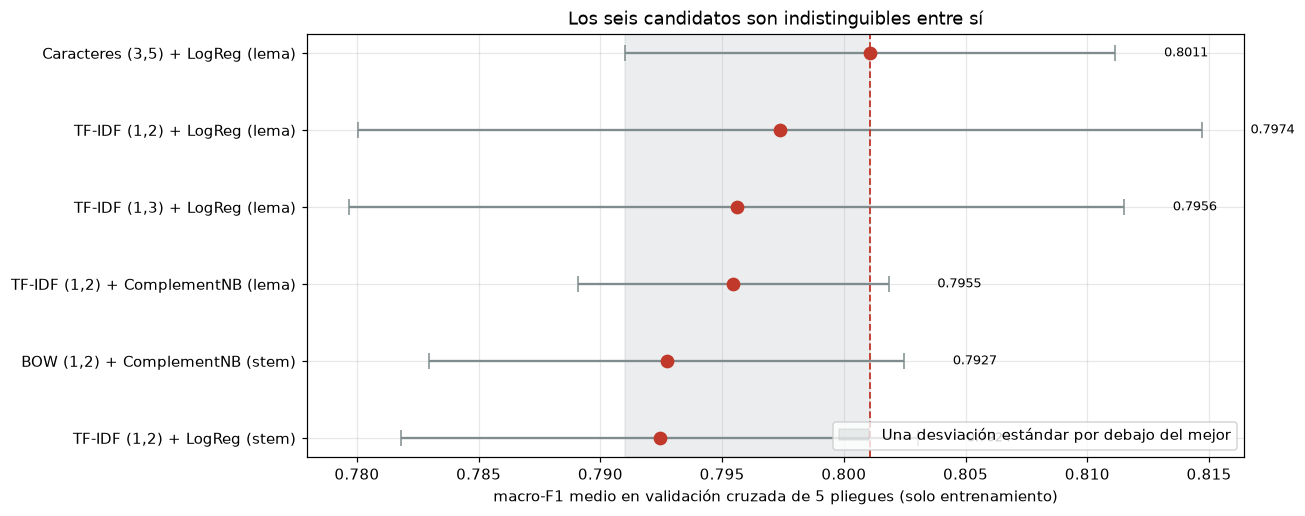

Candidatos dentro de una desviación estándar del mejor: 6 de 6
Amplitud entre el mejor y el peor candidato: 0.0087
Desviación típica entre pliegues del mejor: 0.0101


In [13]:
fig, ax = plt.subplots(figsize=(config.FIG_ANCHO + 1, config.FIG_ALTO))
orden = tabla_cv.sort_values('cv_macro_f1')

ax.errorbar(orden.cv_macro_f1, range(len(orden)), xerr=orden.cv_desviacion,
            fmt='o', color=config.COLOR_DESASTRE, ecolor=config.COLOR_NEUTRO,
            capsize=5, markersize=8, linewidth=1.5)
ax.set_yticks(range(len(orden)))
ax.set_yticklabels(orden.modelo)

techo = tabla_cv.cv_macro_f1.max()
piso = techo - tabla_cv.iloc[0].cv_desviacion
ax.axvspan(piso, techo, color=config.COLOR_NEUTRO, alpha=0.15,
           label='Una desviación estándar por debajo del mejor')
ax.axvline(techo, color=config.COLOR_DESASTRE, linestyle='--', linewidth=1.2)

for i, (_, fila) in enumerate(orden.iterrows()):
    ax.text(fila.cv_macro_f1 + fila.cv_desviacion + 0.002, i,
            f'{fila.cv_macro_f1:.4f}', va='center', fontsize=8.5)

ax.set_xlabel('macro-F1 medio en validación cruzada de 5 pliegues (solo entrenamiento)')
ax.set_title('Los seis candidatos son indistinguibles entre sí')
ax.legend(loc='lower right')
guardar(fig, 'modelos_validacion_cruzada.png')
plt.show()

dentro = tabla_cv[tabla_cv.cv_macro_f1 >= piso]
print(f'Candidatos dentro de una desviación estándar del mejor: {len(dentro)} de {len(tabla_cv)}')
print(f'Amplitud entre el mejor y el peor candidato: '
      f'{tabla_cv.cv_macro_f1.max() - tabla_cv.cv_macro_f1.min():.4f}')
print(f'Desviación típica entre pliegues del mejor: {tabla_cv.iloc[0].cv_desviacion:.4f}')

## Criterio de selección

El criterio se fijó en el plan de trabajo **antes** de ver ningún resultado, que es lo que le
da valor. Se aplica en este orden:

1. **macro-F1 medio en validación cruzada sobre el conjunto de entrenamiento.** Macro-F1 y no
   exactitud, porque las clases están desbalanceadas 57/43 y un clasificador trivial ya
   alcanza 57% de exactitud sin aprender nada. Validación cruzada y no el conjunto de prueba,
   porque el conjunto de prueba no debe participar en la elección.
2. **Si dos modelos quedan dentro de una desviación estándar**, la diferencia no es
   distinguible del ruido y se desempata por el **recall de la clase desastre**: en este
   dominio el error caro es no detectar un desastre real, no dar una falsa alarma.
3. **Si el recall también empata**, se prefiere el modelo más simple e interpretable, porque
   el informe tiene que explicar *qué* aprendió el modelo y no solo cuánto acierta.

In [14]:
techo = tabla_cv.cv_macro_f1.max()
umbral = techo - tabla_cv.iloc[0].cv_desviacion

print('Paso 1 — macro-F1 en validación cruzada')
print(f'  Mejor: {tabla_cv.iloc[0].modelo} con {techo:.4f} '
      f'(desviación {tabla_cv.iloc[0].cv_desviacion:.4f})')
print(f'  Umbral de empate técnico: {umbral:.4f}')

empatados = tabla_cv[tabla_cv.cv_macro_f1 >= umbral].copy()
print(f'  Modelos en empate técnico: {len(empatados)}')
print()

print('Paso 2 — desempate por recall de la clase desastre')
empatados = empatados.sort_values('cv_recall_desastre', ascending=False)
print(empatados[['modelo', 'cv_macro_f1', 'cv_recall_desastre']].round(4).to_string(index=False))
print()

mejor_recall = empatados.cv_recall_desastre.max()
finalistas = empatados[np.isclose(empatados.cv_recall_desastre, mejor_recall, atol=1e-4)]
print(f'Paso 3 — quedan {len(finalistas)} finalistas con recall {mejor_recall:.4f}: '
      f"{', '.join(finalistas.modelo)}")
print('  Se prefiere el más simple e interpretable de ellos.')
print()

GANADOR = 'TF-IDF (1,2) + LogReg (lema)'
print(f'MODELO SELECCIONADO: {GANADOR}')
guardar_tabla(empatados, 'modelos_seleccion_criterio.csv')

Paso 1 — macro-F1 en validación cruzada
  Mejor: Caracteres (3,5) + LogReg (lema) con 0.8011 (desviación 0.0101)
  Umbral de empate técnico: 0.7910
  Modelos en empate técnico: 6

Paso 2 — desempate por recall de la clase desastre
                            modelo  cv_macro_f1  cv_recall_desastre
      TF-IDF (1,2) + LogReg (lema)       0.7974              0.7655
      TF-IDF (1,3) + LogReg (lema)       0.7956              0.7655
  Caracteres (3,5) + LogReg (lema)       0.8011              0.7604
      TF-IDF (1,2) + LogReg (stem)       0.7924              0.7600
TF-IDF (1,2) + ComplementNB (lema)       0.7955              0.7137
   BOW (1,2) + ComplementNB (stem)       0.7927              0.7133

Paso 3 — quedan 2 finalistas con recall 0.7655: TF-IDF (1,2) + LogReg (lema), TF-IDF (1,3) + LogReg (lema)
  Se prefiere el más simple e interpretable de ellos.

MODELO SELECCIONADO: TF-IDF (1,2) + LogReg (lema)
tabla guardada: results/tables/modelos_seleccion_criterio.csv  (6 filas)


**Interpretación.** Los seis candidatos caen dentro de una desviación estándar del mejor, así
que el primer criterio no decide: la elección de representación y algoritmo **no distingue
modelos** en este problema. El desempate por recall de la clase desastre deja empatadas a las
dos variantes de TF-IDF con regresión logística sobre texto lematizado, con rangos (1,2) y
(1,3); entre ellas gana la más simple.

El modelo seleccionado es **el mismo que el avance había elegido de forma preliminar**. La
parrilla completa no lo desbanca: lo confirma. Eso tiene una consecuencia práctica útil, y es
que el ejercicio 10 —que reentrenó sobre el modelo preliminar— sigue midiendo contra el
modelo ganador definitivo, sin necesidad de rehacerlo.

## Diagnóstico del ganador

La tabla comparativa dice cuál modelo es mejor; la matriz de confusión dice **de qué tipo son
los errores que comete**, que es lo que importa para decidir si sirve.

figura guardada: results/figures/modelos_matriz_confusion.png


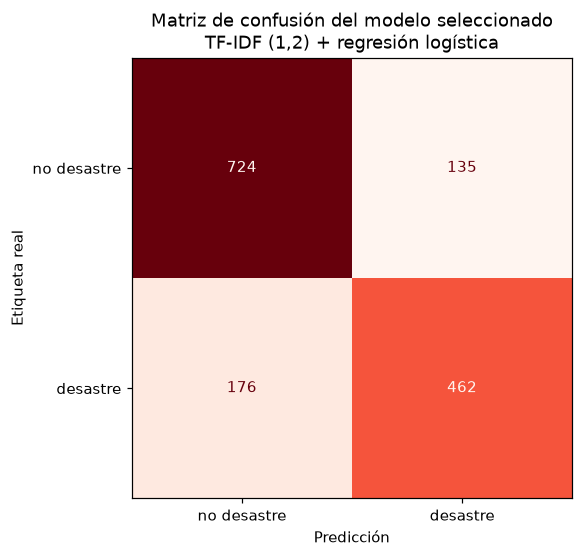

Verdaderos negativos (no desastre, acertado):  724
Falsos positivos     (falsa alarma):           135
Falsos negativos     (desastre no detectado):  176
Verdaderos positivos (desastre detectado):     462

              precision    recall  f1-score   support

 no desastre     0.8044    0.8428    0.8232       859
    desastre     0.7739    0.7241    0.7482       638

    accuracy                         0.7923      1497
   macro avg     0.7892    0.7835    0.7857      1497
weighted avg     0.7914    0.7923    0.7912      1497



In [15]:
pipe_ganador = M.construir_pipeline('logreg', 'tfidf')
fila_ganador = M.evaluar(pipe_ganador, X_tr_clean, y_tr, X_te_clean, y_te, GANADOR)
pred = fila_ganador['prediccion']
confianza = M.puntuar_confianza(pipe_ganador, X_te_clean)

mc = confusion_matrix(y_te, pred, labels=[0, 1])

fig, ax = plt.subplots(figsize=(6, 5.2))
ConfusionMatrixDisplay(confusion_matrix=mc,
                       display_labels=[config.ETIQUETAS[0], config.ETIQUETAS[1]]
                       ).plot(ax=ax, cmap='Reds', colorbar=False, values_format='d')
ax.set_title('Matriz de confusión del modelo seleccionado\n'
             'TF-IDF (1,2) + regresión logística')
ax.set_xlabel('Predicción')
ax.set_ylabel('Etiqueta real')
ax.grid(False)
guardar(fig, 'modelos_matriz_confusion.png')
plt.show()

vn, fp, fn, vp = mc.ravel()
print(f'Verdaderos negativos (no desastre, acertado): {vn:4d}')
print(f'Falsos positivos     (falsa alarma):          {fp:4d}')
print(f'Falsos negativos     (desastre no detectado): {fn:4d}')
print(f'Verdaderos positivos (desastre detectado):    {vp:4d}')
print()
print(classification_report(y_te, pred,
                            target_names=[config.ETIQUETAS[0], config.ETIQUETAS[1]],
                            digits=4))

tabla guardada: results/tables/modelos_coeficientes_top20.csv  (40 filas)


figura guardada: results/figures/modelos_coeficientes.png


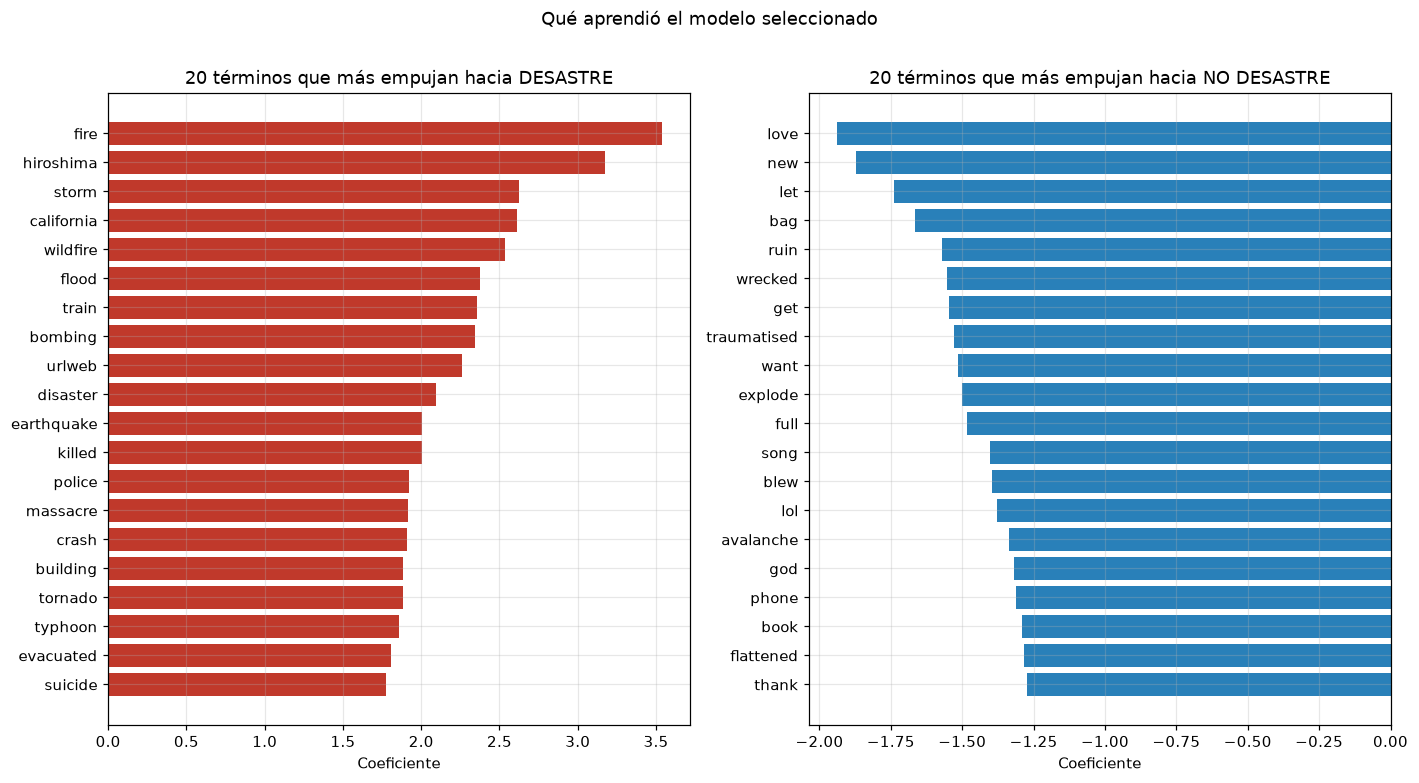

Vocabulario del modelo: 9,308 términos
De ellos, 4,342 son bigramas (46.6%)
Bigramas entre los 20 términos más fuertes de cada lado: 0


In [16]:
vectorizador = pipe_ganador.named_steps['vec']
clasificador = pipe_ganador.named_steps['clf']

coefs = pd.DataFrame({'termino': vectorizador.get_feature_names_out(),
                      'coeficiente': clasificador.coef_[0]})

top_desastre = coefs.nlargest(20, 'coeficiente')
top_no_desastre = coefs.nsmallest(20, 'coeficiente')

guardar_tabla(pd.concat([top_desastre.assign(empuja_hacia='desastre'),
                         top_no_desastre.assign(empuja_hacia='no desastre')]),
              'modelos_coeficientes_top20.csv')

fig, axes = plt.subplots(1, 2, figsize=(config.FIG_ANCHO + 3, config.FIG_ALTO + 2))
axes[0].barh(top_desastre.termino[::-1], top_desastre.coeficiente[::-1],
             color=config.COLOR_DESASTRE)
axes[0].set_title('20 términos que más empujan hacia DESASTRE')
axes[0].set_xlabel('Coeficiente')
axes[1].barh(top_no_desastre.termino[::-1], top_no_desastre.coeficiente[::-1],
             color=config.COLOR_NO_DESASTRE)
axes[1].set_title('20 términos que más empujan hacia NO DESASTRE')
axes[1].set_xlabel('Coeficiente')
fig.suptitle('Qué aprendió el modelo seleccionado', y=1.01)
fig.tight_layout()
guardar(fig, 'modelos_coeficientes.png')
plt.show()

print(f'Vocabulario del modelo: {len(coefs):,} términos')
n_bigramas = sum(' ' in t for t in coefs.termino)
print(f'De ellos, {n_bigramas:,} son bigramas ({n_bigramas / len(coefs) * 100:.1f}%)')
print(f'Bigramas entre los 20 términos más fuertes de cada lado: '
      f"{sum(' ' in t for t in list(top_desastre.termino) + list(top_no_desastre.termino))}")

### Contraste con el análisis de n-gramas

El cuaderno de n-gramas calculó, **sin entrenar ningún modelo**, el log-ratio
`log( P(t | desastre) / P(t | no desastre) )` de cada término. Los coeficientes de la
regresión logística salen de un procedimiento completamente distinto: optimizar una
verosimilitud sobre el conjunto de entrenamiento.

Si las dos medidas coinciden, es una validación cruzada entre dos métodos independientes, y
vale la pena medirla en lugar de afirmarla.

In [17]:
disc = pd.read_csv(config.TABLES / 'ngramas_discriminativo_completo.csv')

top_disc_des = set(disc.nlargest(50, 'logratio').palabra)
top_disc_no = set(disc.nsmallest(50, 'logratio').palabra)

coincide_des = [t for t in top_desastre.termino if t in top_disc_des]
coincide_no = [t for t in top_no_desastre.termino if t in top_disc_no]

print(f'De los 20 términos del modelo que empujan a DESASTRE, {len(coincide_des)} están')
print(f'entre los 50 de mayor log-ratio del análisis de n-gramas:')
print(' ', ', '.join(coincide_des) if coincide_des else '(ninguno)')
print()
print(f'De los 20 que empujan a NO DESASTRE, {len(coincide_no)} están entre los 50 de menor:')
print(' ', ', '.join(coincide_no) if coincide_no else '(ninguno)')

comparacion = coefs.merge(disc[['palabra', 'logratio']], left_on='termino', right_on='palabra')
correlacion = comparacion['coeficiente'].corr(comparacion['logratio'], method='spearman')
print()
print(f'Términos presentes en ambos análisis: {len(comparacion):,}')
print(f'Correlación de Spearman entre coeficiente y log-ratio: {correlacion:.4f}')

De los 20 términos del modelo que empujan a DESASTRE, 5 están
entre los 50 de mayor log-ratio del análisis de n-gramas:
  hiroshima, wildfire, bombing, killed, typhoon

De los 20 que empujan a NO DESASTRE, 5 están entre los 50 de menor:
  bag, ruin, wrecked, song, blew

Términos presentes en ambos análisis: 2,549
Correlación de Spearman entre coeficiente y log-ratio: 0.8590


## Análisis de errores: de qué se equivoca el modelo

Contar errores no explica nada. Lo que explica es **de qué tipo son**, y eso exige leerlos.

Se toma una **muestra aleatoria** de 10 falsos positivos y 10 falsos negativos —aleatoria y no
los más confiados, porque los extremos de la distribución de confianza no son representativos
del error típico— y se clasifica cada caso a mano en una de seis categorías:

| Categoría | Qué significa |
|---|---|
| `uso figurado` | Vocabulario de catástrofe usado como metáfora, símil o hipótesis |
| `contexto inofensivo` | La palabra es literal, pero el hecho no es un desastre |
| `texto insuficiente` | El tweet casi no tiene texto: enlaces, hashtags o menciones |
| `vocabulario de noticias` | Léxico de medios o servicios de emergencia sin evento detrás |
| `etiqueta discutible` | La anotación del conjunto de datos es difícil de justificar |
| `ambigüedad genuina` | Ni una persona decidiría con seguridad |

La tipificación va escrita como un diccionario explícito de `id` a categoría. No se calcula:
se juzga, y queda a la vista para que cualquiera pueda discrepar de un caso concreto.

In [18]:
diagnostico = prueba.assign(pred=pred, confianza=confianza)
falsos_positivos = diagnostico[(diagnostico.target == 0) & (diagnostico.pred == 1)]
falsos_negativos = diagnostico[(diagnostico.target == 1) & (diagnostico.pred == 0)]

muestra_fp = falsos_positivos.sample(10, random_state=config.SEED)
muestra_fn = falsos_negativos.sample(10, random_state=config.SEED)

# Tipificación hecha a mano, leyendo cada tweet.
TIPO_ERROR = {
    # Falsos positivos: el modelo dijo "desastre" y la etiqueta dice que no
    7228: 'uso figurado',           # "if you were a natural disaster what would you be?"
    5323: 'uso figurado',           # "that song just ended setting myself on fire"
    2046: 'uso figurado',           # cita de House of Cards sobre "hypocrisy and casualties"
    3938: 'uso figurado',           # "devastated by today's allegations"
    9660: 'uso figurado',           # "better than tornado!"
    1852: 'contexto inofensivo',    # "burned 202 calories walking"
    8111: 'contexto inofensivo',    # perros cocker "rescued then abandoned"
    7771: 'texto insuficiente',     # dos menciones y un enlace, sin texto propio
    9486: 'texto insuficiente',     # "Truth..." más nueve hashtags de noticias
    5049: 'vocabulario de noticias',  # "#TBT Eyewitness News WBRE WYOU"

    # Falsos negativos: la etiqueta dice "desastre" y el modelo no lo detectó
    1245: 'etiqueta discutible',    # "high blood pressure. Life is stressful"
    8880: 'etiqueta discutible',    # "I get to smoke my shit in peace"
    2275: 'etiqueta discutible',    # "Fall off a cliff please" (insulto)
    4580: 'etiqueta discutible',    # consejo de tener un plan de emergencia, sin evento
    1051: 'etiqueta discutible',    # "I waited 2.5 hours for a cab my feet are bleeding"
    7860: 'etiqueta discutible',    # subreddits "banned or quarantined"
    10583: 'etiqueta discutible',   # alza de tarifas de una aseguradora de tormentas
    7147: 'etiqueta discutible',    # "It looks like a mudslide!" sobre un pastel (#GBBO)
    3057: 'texto insuficiente',     # "Silence." más hashtags: naufragio real, casi sin texto
    8926: 'ambigüedad genuina',     # "I remember those days. In a snowstorm too."
}

muestra = pd.concat([
    muestra_fp.assign(tipo_error='falso positivo'),
    muestra_fn.assign(tipo_error='falso negativo'),
])
muestra['categoria'] = muestra['id'].map(TIPO_ERROR)

faltan = muestra[muestra.categoria.isna()]
assert faltan.empty, f'Sin tipificar: {list(faltan.id)}'

tabla_errores = (muestra.groupby(['tipo_error', 'categoria']).size()
                 .rename('casos').reset_index()
                 .sort_values(['tipo_error', 'casos'], ascending=[True, False]))
guardar_tabla(tabla_errores, 'modelos_errores_tipificados.csv')
tabla_errores

tabla guardada: results/tables/modelos_errores_tipificados.csv  (7 filas)


,tipo_error,categoria,casos
1,falso negativo,etiqueta discutible,8
0,falso negativo,ambigüedad genuina,1
2,falso negativo,texto insuficiente,1
5,falso positivo,uso figurado,5
3,falso positivo,contexto inofensivo,2
4,falso positivo,texto insuficiente,2
6,falso positivo,vocabulario de noticias,1


figura guardada: results/figures/modelos_tipos_error.png


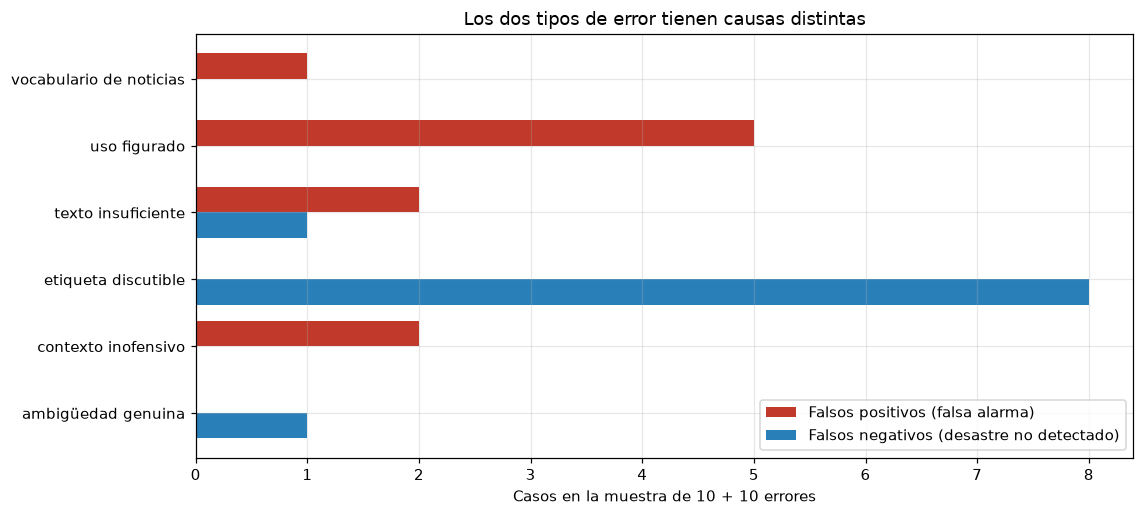

De los 10 falsos negativos muestreados, 8 son casos donde la etiqueta del conjunto de datos es difícil de justificar.
De los 10 falsos positivos, 5 son uso figurado del vocabulario de catástrofe.


In [19]:
resumen_fp = muestra[muestra.tipo_error == 'falso positivo'].categoria.value_counts()
resumen_fn = muestra[muestra.tipo_error == 'falso negativo'].categoria.value_counts()
categorias = sorted(set(resumen_fp.index) | set(resumen_fn.index))

fig, ax = plt.subplots(figsize=(config.FIG_ANCHO + 1, config.FIG_ALTO))
y = np.arange(len(categorias))
altura = 0.38
ax.barh(y + altura / 2, [resumen_fp.get(c, 0) for c in categorias], altura,
        label='Falsos positivos (falsa alarma)', color=config.COLOR_DESASTRE)
ax.barh(y - altura / 2, [resumen_fn.get(c, 0) for c in categorias], altura,
        label='Falsos negativos (desastre no detectado)', color=config.COLOR_NO_DESASTRE)
ax.set_yticks(y)
ax.set_yticklabels(categorias)
ax.set_xlabel('Casos en la muestra de 10 + 10 errores')
ax.set_title('Los dos tipos de error tienen causas distintas')
ax.legend(loc='lower right')
guardar(fig, 'modelos_tipos_error.png')
plt.show()

n_etiqueta_fn = resumen_fn.get('etiqueta discutible', 0)
print(f'De los 10 falsos negativos muestreados, {n_etiqueta_fn} son casos donde la etiqueta '
      f'del conjunto de datos es difícil de justificar.')
print(f'De los 10 falsos positivos, {resumen_fp.get("uso figurado", 0)} son uso figurado del '
      f'vocabulario de catástrofe.')

In [20]:
# Los errores más confiados, como ilustración: donde el modelo se equivoca sin dudar.
ejemplos = pd.concat([
    falsos_positivos.nlargest(5, 'confianza').assign(tipo_error='falso positivo'),
    falsos_negativos.nsmallest(5, 'confianza').assign(tipo_error='falso negativo'),
])[['id', 'tipo_error', 'keyword_norm', 'confianza', 'target', 'pred', 'text']]

guardar_tabla(ejemplos, 'modelos_ejemplos_errores.csv')

for _, fila in ejemplos.iterrows():
    print(f"[{fila.tipo_error}] confianza={fila.confianza:.3f}  keyword={fila.keyword_norm}")
    print(f"   {fila.text[:150]}")
    print()

tabla guardada: results/tables/modelos_ejemplos_errores.csv  (10 filas)
[falso positivo] confianza=0.902  keyword=storm
   this storm????

[falso positivo] confianza=0.855  keyword=oil spill
   @TroySlaby22 slicker than an oil spill

[falso positivo] confianza=0.820  keyword=cyclone
   'I'm a cyclone passion overblown' https://t.co/MmZgpHNKNP

[falso positivo] confianza=0.815  keyword=collision
   Santa Fe Springs Studebaker Rd / South St **Trfc Collision-No Inj** http://t.co/6uHih9pbrU

[falso positivo] confianza=0.815  keyword=fire
   My asshole is on fire  https://t.co/Y3FO0gHg8t

[falso negativo] confianza=0.071  keyword=wrecked
   @Kirafrog @mount_wario Did you get wrecked again?

[falso negativo] confianza=0.103  keyword=panicking
   all that panicking made me tired ;__; i want to sleep in my bed

[falso negativo] confianza=0.121  keyword=trouble
   @lucysforsale funny cause my dumb ass was the young one to get n trouble the most lol

[falso negativo] confianza=0.125  keyword=cat

**Interpretación.** Los dos tipos de error no se parecen en nada, y esa asimetría es el
hallazgo central del ejercicio.

Los **falsos positivos** son en su mayoría errores reales del modelo, y casi todos del mismo
tipo: **uso figurado** del vocabulario de catástrofe. *"If you were a natural disaster what
would you be?"*, *"devastated by today's allegations"*, *"burned 202 calories walking"*. El
modelo no tiene forma de distinguirlos porque su representación es una bolsa de palabras: ve
`disaster`, `devastated`, `burned`, y esas palabras efectivamente predicen desastre en el
resto del corpus. Es exactamente el fallo que el análisis exploratorio anticipó al observar
que los errores se concentrarían en las keywords de tasa intermedia.

Los **falsos negativos** son otra cosa. En la muestra, ocho de diez son casos donde **la
etiqueta del conjunto de datos es la que cuesta defender**: *"Fall off a cliff please"* como
insulto, *"It looks like a mudslide!"* dicho sobre un pastel en un programa de repostería,
*"my feet are bleeding"* después de esperar un taxi. Todos vienen marcados como desastre real.
El modelo predice "no desastre" y, leído el tweet, es difícil darle la razón a la anotación.

Esto no significa que el modelo sea mejor de lo que dice su métrica. Significa que **una parte
del error medido no es error del modelo sino ruido de la anotación**, y que ese ruido pone un
techo al desempeño alcanzable que ningún algoritmo puede superar. Es la misma conclusión a la
que llegó el análisis de los datos por otra vía, cuando encontró 18 textos idénticos
etiquetados a la vez como desastre y como no desastre.

Una advertencia metodológica sobre esta lectura: la muestra es de 20 errores sobre 311, así
que las proporciones tienen una incertidumbre grande y no deben leerse como una estimación
precisa. Lo que sí sostiene la muestra es la diferencia cualitativa entre los dos tipos de
error, que es marcada y consistente.

## El modelo seleccionado

**TF-IDF con rango de n-gramas (1,2) y `min_df=2`, más regresión logística con
`class_weight='balanced'`, entrenado sobre `text_clean` (texto limpio y lematizado).**

Se guarda el `Pipeline` completo, no solo el clasificador. Esa distinción importa: el objeto
serializado incluye el vectorizador ya ajustado, con su vocabulario y sus pesos IDF, así que
`clasificar_tweet()` puede recibir un tweet crudo y no necesita reconstruir nada. Guardar solo
el clasificador obligaría a quien lo cargue a reproducir la vectorización por su cuenta, y
cualquier diferencia mínima produciría predicciones distintas sin ningún aviso.

In [21]:
joblib.dump(pipe_ganador, M.MEJOR_MODELO)
print(f'Modelo guardado en results/modelos/{M.MEJOR_MODELO.name}')

# Verificación de que el objeto guardado sirve por sí solo.
recargado = joblib.load(M.MEJOR_MODELO)
assert (recargado.predict(X_te_clean) == pred).all(), 'El modelo recargado no coincide.'
print('Verificado: el modelo recargado reproduce las mismas predicciones.')

print()
print('Resumen del ejercicio 6')
print('=' * 62)
print(f'  Combinaciones evaluadas ....... {len(resultados)} en la parrilla '
      f'+ {len(contexto)} variantes de contexto')
print(f'  Modelo seleccionado ........... {GANADOR}')
print(f'  macro-F1 en validación cruzada  {tabla_cv[tabla_cv.modelo == GANADOR].cv_macro_f1.iloc[0]:.4f} '
      f'± {tabla_cv[tabla_cv.modelo == GANADOR].cv_desviacion.iloc[0]:.4f}')
print(f'  macro-F1 en el conjunto de prueba {fila_ganador["macro_f1"]:.4f}')
print(f'  Exactitud ..................... {fila_ganador["accuracy"]:.4f}')
print(f'  Recall de la clase desastre ... {fila_ganador["recall_desastre"]:.4f}')
print(f'  Baseline de clase mayoritaria . 0.3646 de macro-F1')

Modelo guardado en results/modelos/mejor_modelo.joblib
Verificado: el modelo recargado reproduce las mismas predicciones.

Resumen del ejercicio 6
  Combinaciones evaluadas ....... 14 en la parrilla + 5 variantes de contexto
  Modelo seleccionado ........... TF-IDF (1,2) + LogReg (lema)
  macro-F1 en validación cruzada  0.7974 ± 0.0173
  macro-F1 en el conjunto de prueba 0.7857
  Exactitud ..................... 0.7923
  Recall de la clase desastre ... 0.7241
  Baseline de clase mayoritaria . 0.3646 de macro-F1
